# Linear Regression 

**Goal:** Predict `SalePrice` of houses in Ames, Iowa using Linear Regression and its regularized variants.

Every other model you learn will be compared against linear regression. It's the baseline. It's also the most interpretable — you can read the coefficients and explain exactly why a house costs what it does. Understanding it deeply makes everything else easier.



## Imports

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew

from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)

print("Imports ready ✓")

Imports ready ✓


## 1. Load Data

In [35]:
TRAIN_PATH = '../../Datasets/HousePrice/train.csv'
TEST_PATH  = '../../Datasets/HousePrice/test.csv'

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print(f"Train: {train.shape[0]:,} rows, {train.shape[1]} columns")
print(f"Test:  {test.shape[0]:,} rows,  {test.shape[1]} columns")
print(f"Test has no SalePrice column — that's what we predict at the end.")
print()
train.head(3)

Train: 1,460 rows, 81 columns
Test:  1,459 rows,  80 columns
Test has no SalePrice column — that's what we predict at the end.



,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,...,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,...,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,...,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


## 2. EDA — Know Your Data Before Touching It

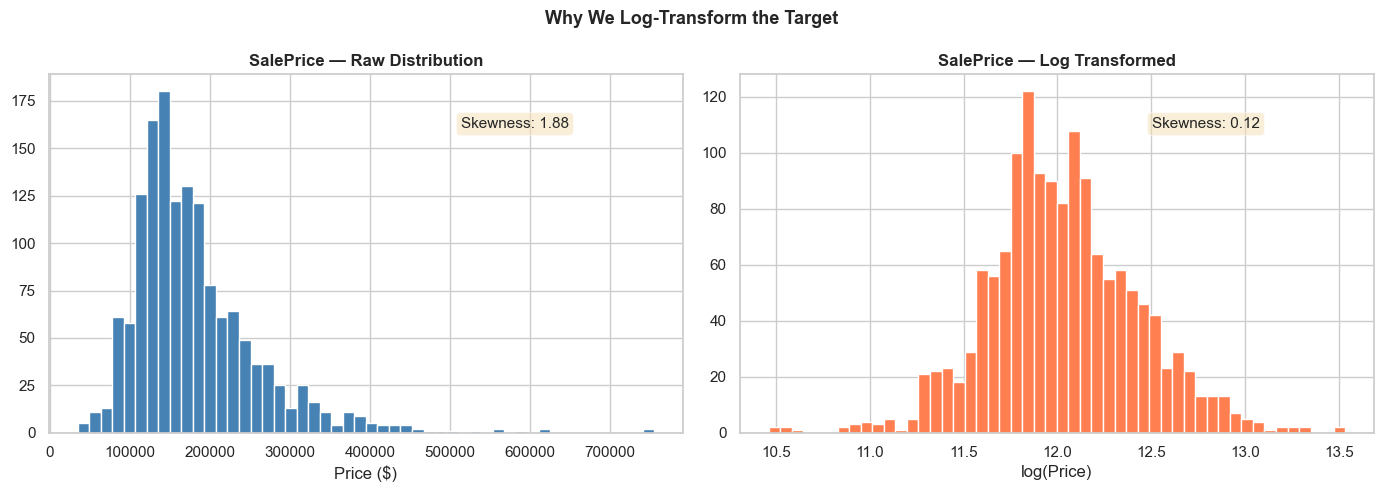

Raw skewness:  1.883  — heavily right-skewed
Log skewness:  0.121  — much more normal

We will train on log(SalePrice) and exponentiate predictions at the end.
This also means our error metric (RMSE) is in log scale — same as Kaggle's scoring.


In [36]:
# Target variable first — always understand what you're predicting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(train['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice — Raw Distribution', fontweight='bold')
axes[0].set_xlabel('Price ($)')
skew_raw = train['SalePrice'].skew()
axes[0].text(0.65, 0.85, f'Skewness: {skew_raw:.2f}', transform=axes[0].transAxes,
             fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Log distribution
axes[1].hist(np.log1p(train['SalePrice']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('SalePrice — Log Transformed', fontweight='bold')
axes[1].set_xlabel('log(Price)')
skew_log = np.log1p(train['SalePrice']).skew()
axes[1].text(0.65, 0.85, f'Skewness: {skew_log:.2f}', transform=axes[1].transAxes,
             fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Why We Log-Transform the Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Raw skewness:  {skew_raw:.3f}  — heavily right-skewed")
print(f"Log skewness:  {skew_log:.3f}  — much more normal")
print()
print("We will train on log(SalePrice) and exponentiate predictions at the end.")
print("This also means our error metric (RMSE) is in log scale — same as Kaggle's scoring.")

Missing: Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64, Value Count: 81 


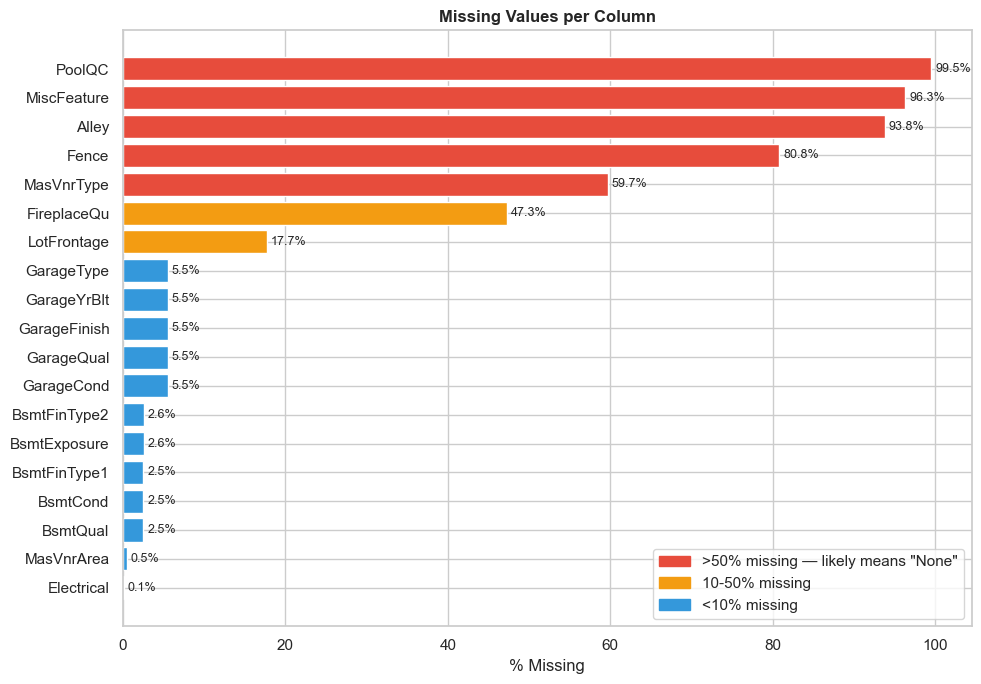

KEY INSIGHT: Most missing values here mean 'None/Not Applicable'
e.g. PoolQC=NaN means 'No Pool', not 'We don't know the pool quality'
This is critical — we fill them with 'None'/'0', NOT with mean/median


In [37]:
# Missing values — this dataset has a LOT, and the reason matters
missing = train.isnull().sum()
print(f'Missing: {missing}, Value Count: {missing.value_counts().sum()} ')
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if p > 50 else '#f39c12' if p > 10 else '#3498db'
          for p in missing_pct.values]
bars = ax.barh(missing.index, missing_pct.values, color=colors, edgecolor='white')
ax.set_xlabel('% Missing')
ax.set_title('Missing Values per Column', fontweight='bold')
for bar, pct in zip(bars, missing_pct.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9)
ax.invert_yaxis()

from matplotlib.patches import Patch
legend = [Patch(color='#e74c3c', label='>50% missing — likely means "None"'),
          Patch(color='#f39c12', label='10-50% missing'),
          Patch(color='#3498db', label='<10% missing')]
ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.show()

print("KEY INSIGHT: Most missing values here mean 'None/Not Applicable'")
print("e.g. PoolQC=NaN means 'No Pool', not 'We don't know the pool quality'")
print("This is critical — we fill them with 'None'/'0', NOT with mean/median")

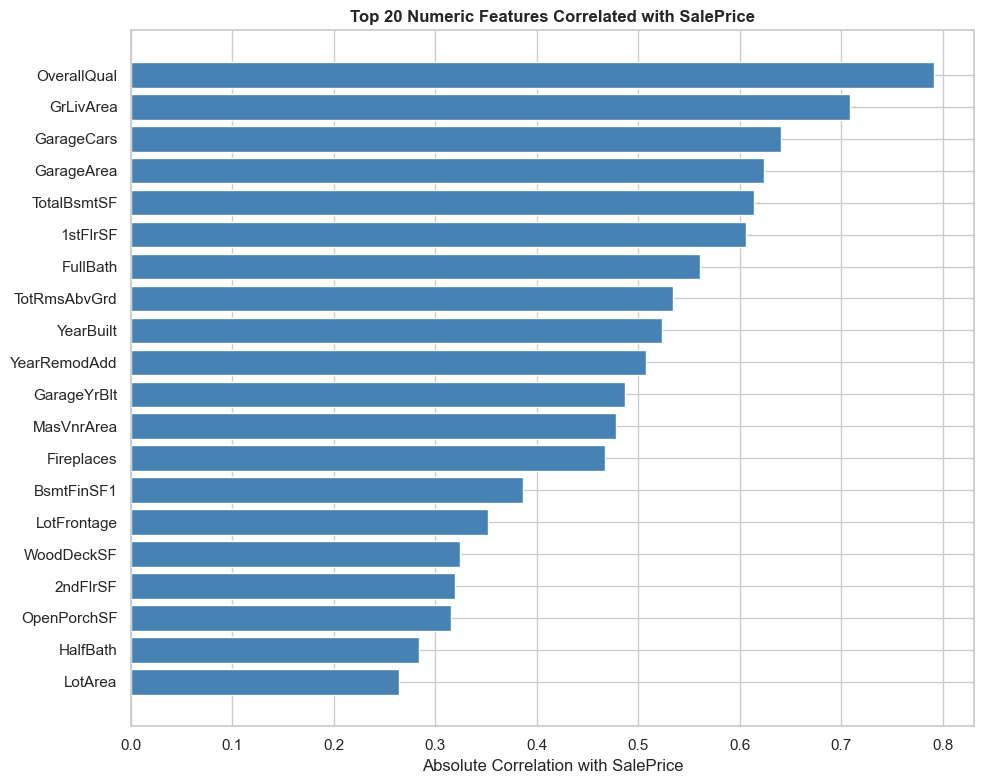

Top 5 most correlated features:
  OverallQual          +0.791
  GrLivArea            +0.709
  GarageCars           +0.640
  GarageArea           +0.623
  TotalBsmtSF          +0.614


In [38]:
# Top numeric correlations with SalePrice
num_cols = train.select_dtypes(include=np.number).columns.drop(['Id', 'SalePrice'])
corr = train[num_cols].corrwith(train['SalePrice']).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ecc71' if v > 0 else '#e74c3c'
          for v in train[num_cols].corrwith(train['SalePrice']).reindex(corr.index)]
ax.barh(corr.index[:20], corr.values[:20], color='steelblue', edgecolor='white')
ax.set_xlabel('Absolute Correlation with SalePrice')
ax.set_title('Top 20 Numeric Features Correlated with SalePrice', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 most correlated features:")
for feat, val in corr.head(5).items():
    direction = train[feat].corr(train['SalePrice'])
    sign = '+' if direction > 0 else '-'
    print(f"  {feat:<20} {sign}{val:.3f}")

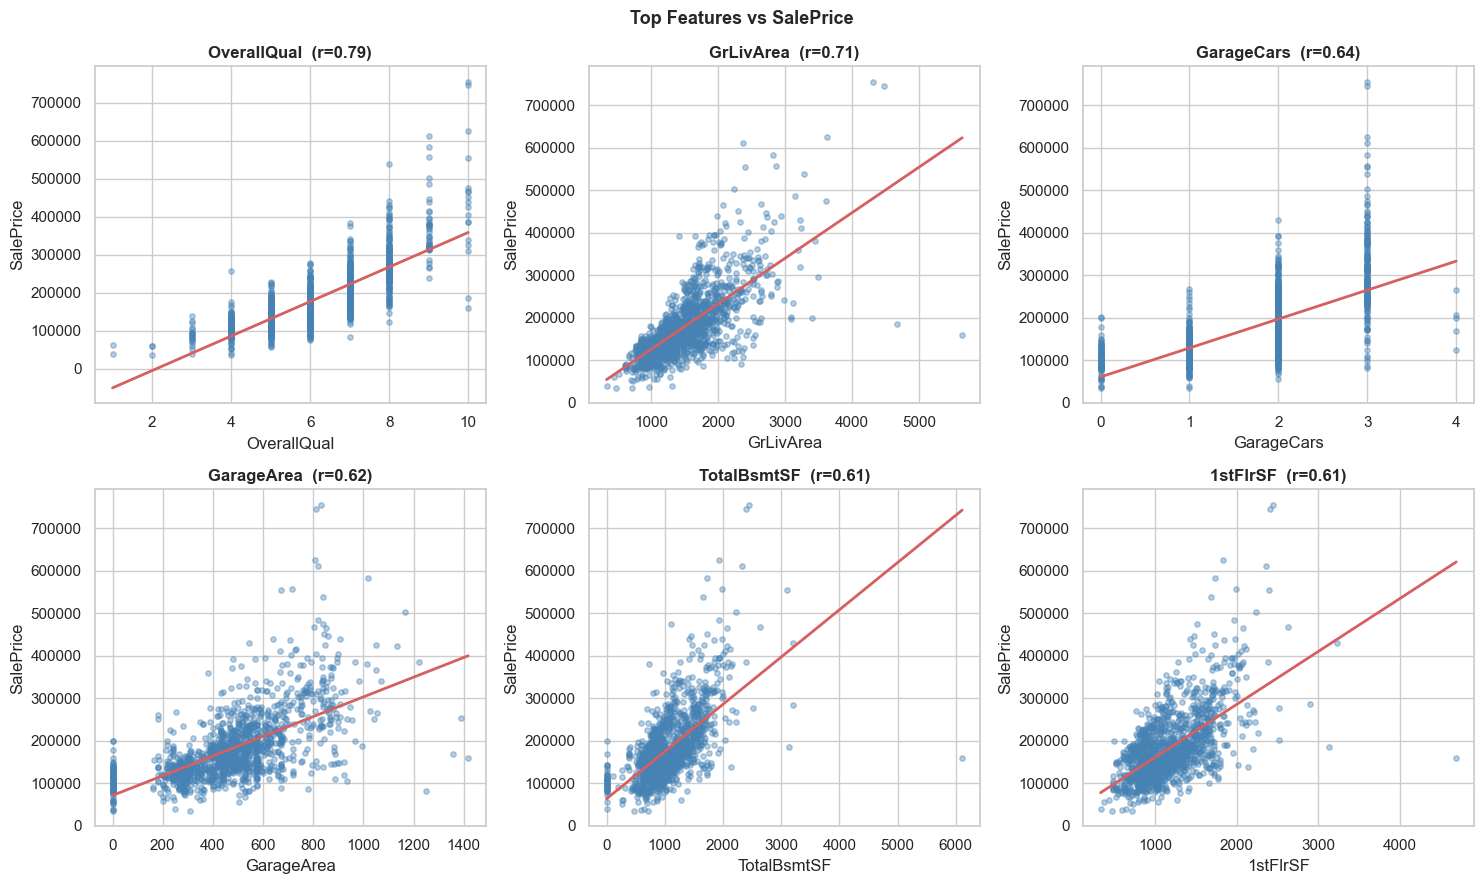

In [39]:
# Scatter plots — top features vs SalePrice
top_feats = corr.index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feat in enumerate(top_feats):
    axes[i].scatter(train[feat], train['SalePrice'],
                    alpha=0.4, s=15, color='steelblue')
    # Trend line
    mask = train[feat].notna()
    m, b = np.polyfit(train.loc[mask, feat], train.loc[mask, 'SalePrice'], 1)
    x_range = np.linspace(train[feat].min(), train[feat].max(), 100)
    axes[i].plot(x_range, m*x_range + b, 'r-', lw=2)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('SalePrice')
    r = train[feat].corr(train['SalePrice'])
    axes[i].set_title(f'{feat}  (r={r:.2f})', fontweight='bold')

plt.suptitle('Top Features vs SalePrice', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

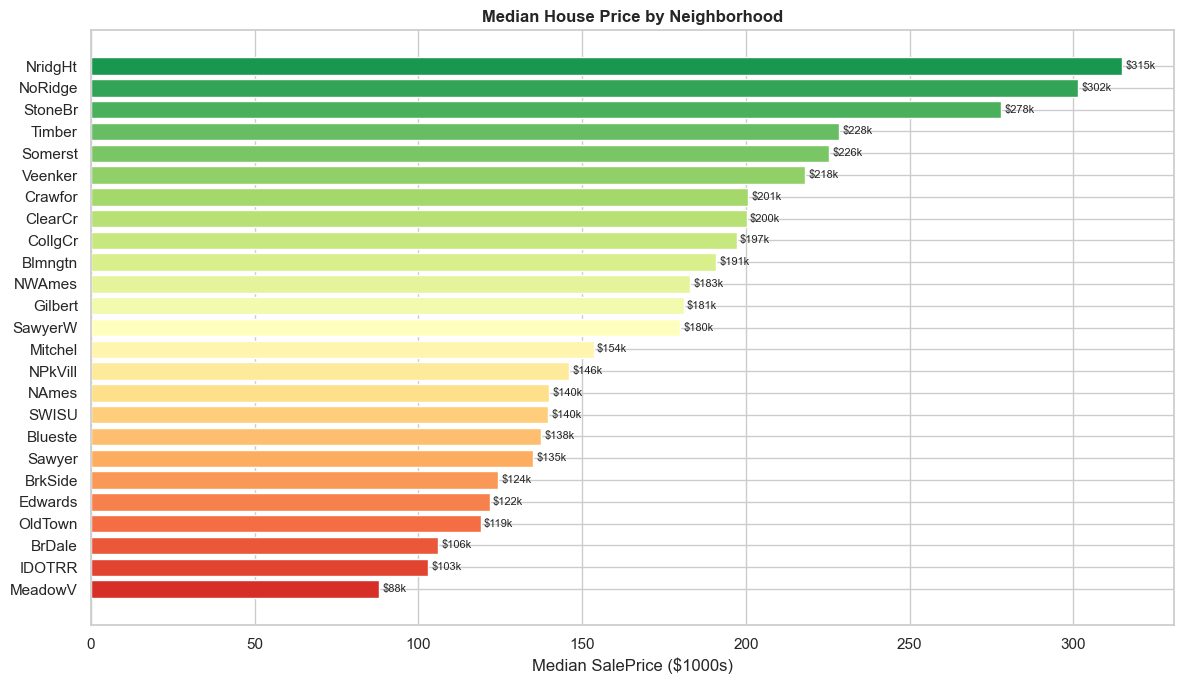

Cheapest neighborhood: MeadowV  — $88,000
Priciest neighborhood: NridgHt — $315,000
That's a 3.6x difference — neighborhood is hugely important


In [40]:
# Neighborhood matters a lot — visualize median prices
neighborhood_price = train.groupby('Neighborhood')['SalePrice'].median().sort_values()

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(neighborhood_price.index, neighborhood_price.values / 1000,
               color=plt.cm.RdYlGn(
                   np.linspace(0.1, 0.9, len(neighborhood_price))),
               edgecolor='white')
ax.set_xlabel('Median SalePrice ($1000s)')
ax.set_title('Median House Price by Neighborhood', fontweight='bold')
for bar, val in zip(bars, neighborhood_price.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'${val/1000:.0f}k', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Cheapest neighborhood: {neighborhood_price.index[0]}  — ${neighborhood_price.iloc[0]:,.0f}")
print(f"Priciest neighborhood: {neighborhood_price.index[-1]} — ${neighborhood_price.iloc[-1]:,.0f}")
print(f"That's a {neighborhood_price.iloc[-1]/neighborhood_price.iloc[0]:.1f}x difference — neighborhood is hugely important")


> **The most important EDA finding:** Most NaNs in this dataset mean "feature doesn't exist", NOT "data is missing".
> Treating them as missing and filling with mean would be completely wrong.


In [41]:
def handle_missing(df):
    df = df.copy()

    # --- Group 1: NaN means "No Feature" — fill with 'None' ---
    # From data_description.txt: NA = No Pool, No Garage, No Basement, etc.
    none_cols = [
        'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
        'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
        'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
        'MasVnrType'
    ]
    for col in none_cols:
        if col in df.columns:
            df[col] = df[col].fillna('None')

    # --- Group 2: NaN means 0 area/count (no feature = no area) ---
    zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
                 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
    for col in zero_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # --- Group 3: LotFrontage — genuinely missing, use neighborhood median ---
    # Houses in the same neighborhood tend to have similar lot frontage
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )

    # --- Group 4: Single missing values — use mode ---
    for col in ['Electrical', 'MSZoning', 'Utilities', 'Functional',
                'Exterior1st', 'Exterior2nd', 'KitchenQual', 'SaleType']:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].mode()[0])

    return df

train = handle_missing(train)
test  = handle_missing(test)

# Verify
remaining_train = train.isnull().sum().sum()
remaining_test  = test.isnull().sum().sum()
print(f"Missing values remaining — Train: {remaining_train}, Test: {remaining_test}")
print("All handled ✓")

Missing values remaining — Train: 0, Test: 0
All handled ✓


## 4. Feature Engineering

In [42]:
def engineer_features(df):
    df = df.copy()

    # --- Total area features ---
    # Buyers think in total space, not individual room sq footages
    df['TotalSF']       = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBathrooms'] = (df['FullBath'] + df['BsmtFullBath'] +
                            0.5 * df['HalfBath'] + 0.5 * df['BsmtHalfBath'])
    df['TotalPorchSF']  = (df['OpenPorchSF'] + df['EnclosedPorch'] +
                           df['3SsnPorch'] + df['ScreenPorch'])

    # --- Age features ---
    df['HouseAge']     = df['YrSold'] - df['YearBuilt']
    df['RemodAge']     = df['YrSold'] - df['YearRemodAdd']
    df['WasRemodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
    df['IsNew']        = (df['YrSold'] == df['YearBuilt']).astype(int)

    # --- Quality scores — combine quality + condition ---
    # OverallQual is already numeric (1-10), very powerful feature
    df['QualCond']     = df['OverallQual'] * df['OverallCond']

    # --- Has features flags ---
    df['HasPool']      = (df['PoolArea'] > 0).astype(int)
    df['HasGarage']    = (df['GarageArea'] > 0).astype(int)
    df['HasBasement']  = (df['TotalBsmtSF'] > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)

    # --- Neighborhood quality score (target encoding proxy) ---
    # We'll do this properly on train data only later

    return df

train = engineer_features(train)
test  = engineer_features(test)

new_feats = ['TotalSF', 'TotalBathrooms', 'TotalPorchSF', 'HouseAge',
             'RemodAge', 'WasRemodeled', 'IsNew', 'QualCond',
             'HasPool', 'HasGarage', 'HasBasement', 'HasFireplace']

print("New features created:")
print(train[new_feats].describe().round(2))

New features created:
        TotalSF  TotalBathrooms  TotalPorchSF  HouseAge  RemodAge  \
count   1460.00         1460.00       1460.00   1460.00   1460.00   
mean    2567.05            2.21         87.08     36.55     22.95   
std      821.71            0.79        105.19     30.25     20.64   
min      334.00            1.00          0.00      0.00     -1.00   
25%     2009.50            2.00          0.00      8.00      4.00   
50%     2474.00            2.00         48.00     35.00     14.00   
75%     3004.00            2.50        136.00     54.00     41.00   
max    11752.00            6.00       1027.00    136.00     60.00   

       WasRemodeled    IsNew  QualCond  HasPool  HasGarage  HasBasement  \
count       1460.00  1460.00   1460.00  1460.00    1460.00      1460.00   
mean           0.48     0.04     33.86     0.00       0.94         0.97   
std            0.50     0.20      9.22     0.07       0.23         0.16   
min            0.00     0.00      1.00     0.00       0.

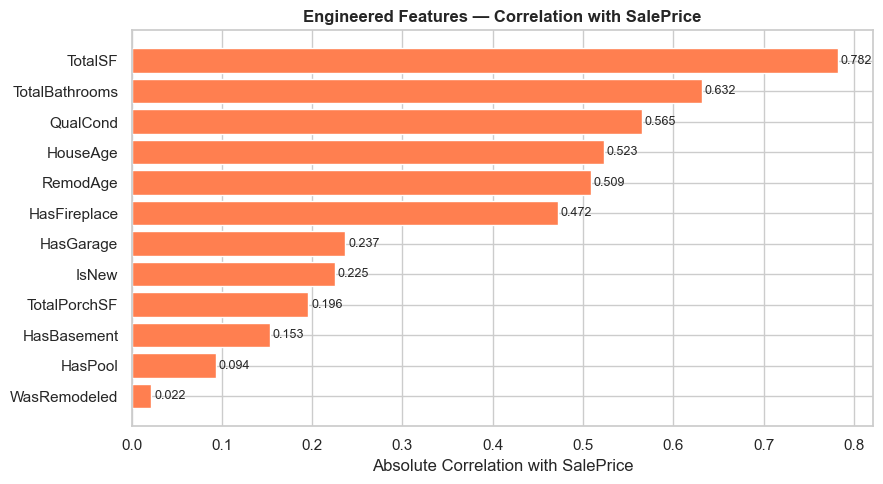

TotalSF is our best engineered feature — buyers think in total space, not per-room.


In [43]:
# Check new feature correlations with SalePrice
new_corr = train[new_feats].corrwith(train['SalePrice']).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(new_corr.index, new_corr.values, color='coral', edgecolor='white')
ax.set_xlabel('Absolute Correlation with SalePrice')
ax.set_title('Engineered Features — Correlation with SalePrice', fontweight='bold')
ax.invert_yaxis()
for i, (feat, val) in enumerate(new_corr.items()):
    ax.text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("TotalSF is our best engineered feature — buyers think in total space, not per-room.")

## 5. Encoding Categorical Variables

In [44]:
# Ordinal encoding — quality/condition columns have a natural order
# Ex=5, Gd=4, TA=3, Fa=2, Po=1, None=0
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

ordinal_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2',
    'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC'
]

bsmt_exposure_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}
bsmt_fin_map      = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}
functional_map    = {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4,
                     'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0}
garage_finish_map = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0}
paved_map         = {'Y': 2, 'P': 1, 'N': 0}
land_slope_map    = {'Gtl': 0, 'Mod': 1, 'Sev': 2}

for df in [train, test]:
    for col in ordinal_cols:
        if col == 'BsmtExposure':
            df[col] = df[col].map(bsmt_exposure_map).fillna(0)
        elif col in ['BsmtFinType1', 'BsmtFinType2']:
            df[col] = df[col].map(bsmt_fin_map).fillna(0)
        else:
            df[col] = df[col].map(qual_map).fillna(0)

    df['Functional']   = df['Functional'].map(functional_map).fillna(7)
    df['GarageFinish'] = df['GarageFinish'].map(garage_finish_map).fillna(0)
    df['PavedDrive']   = df['PavedDrive'].map(paved_map).fillna(0)
    df['LandSlope']    = df['LandSlope'].map(land_slope_map).fillna(0)
    df['CentralAir']   = df['CentralAir'].map({'Y': 1, 'N': 0})

print("Ordinal encoding done")
print()
print("Sample — KitchenQual before/after:")
print("  Ex=5, Gd=4, TA=3, Fa=2, Po=1 — preserves the order")

Ordinal encoding done

Sample — KitchenQual before/after:
  Ex=5, Gd=4, TA=3, Fa=2, Po=1 — preserves the order


In [45]:
# One-hot encoding for nominal categoricals
# drop_first=True avoids the dummy variable trap (multicollinearity)
nominal_cols = [
    'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
    'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
    'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
    'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'GarageType',
    'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'
]

# Combine train and test before OHE to ensure same columns
all_data = pd.concat([train.drop('SalePrice', axis=1), test], axis=0, ignore_index=True)
all_data = pd.get_dummies(all_data, columns=nominal_cols, drop_first=True, dtype=int)

# Split back
X_all   = all_data.iloc[:len(train)].copy()
X_test  = all_data.iloc[len(train):].copy()

print(f"Features after encoding: {X_all.shape[1]}")
print(f"(started with 81 columns, now {X_all.shape[1]} after OHE + feature engineering)")

Features after encoding: 220
(started with 81 columns, now 220 after OHE + feature engineering)


## 6. Prepare for Modelling

In [46]:
# Log-transform skewed numeric features
# Rule of thumb: |skewness| > 0.75 — apply log1p
numeric_feats = X_all.select_dtypes(include=np.number).columns

skewness = X_all[numeric_feats].apply(lambda x: skew(x.dropna()))
skewed_feats = skewness[abs(skewness) > 0.75].index.tolist()

print(f"Features with |skewness| > 0.75: {len(skewed_feats)}")
print("Applying log1p transform...")

for feat in skewed_feats:
    X_all[feat]  = np.log1p(X_all[feat].clip(lower=0))
    X_test[feat] = np.log1p(X_test[feat].clip(lower=0))

print("Done ✓")

Features with |skewness| > 0.75: 186
Applying log1p transform...
Done ✓


In [47]:
# Target: log-transform SalePrice (Kaggle scores on log RMSE)
y = np.log1p(train['SalePrice'])

# Drop ID column
X_all  = X_all.drop(columns=['Id'], errors='ignore')
X_test = X_test.drop(columns=['Id'], errors='ignore')

# Fill any remaining NaNs (edge cases)
X_all  = X_all.fillna(0)
X_test = X_test.fillna(0)

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"Target (log SalePrice): min={y.min():.3f}, max={y.max():.3f}, mean={y.mean():.3f}")

X_train: (1168, 219)
X_val:   (292, 219)
Target (log SalePrice): min=10.460, max=13.534, mean=12.024


## 7. Linear Regression 

**The math behind it:**

Linear Regression finds weights (coefficients) w such that:

```
y_hat = w0 + w1*x1 + w2*x2 + ... + wn*xn
```

It minimizes **Mean Squared Error**:
```
MSE = (1/n) * sum((y - y_hat)^2)
```

The closed-form solution (what sklearn computes):
```
w = (X^T X)^(-1) X^T y
```

This is exactly the matrix inverse from your Linear Algebra file — now you see it in action.


In [51]:
# Scale features — critical for Linear Regression
# RobustScaler uses median/IQR instead of mean/std — handles outliers better
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# Train
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

# Predict
y_pred_val = lr.predict(X_val_sc)

# Metrics — using RMSE on log scale (same as Kaggle)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2   = r2_score(y_val, y_pred_val)
mae  = mean_absolute_error(y_val, y_pred_val)

print("=== Linear Regression Results ===")
print(f"  RMSE (log scale): {rmse:.5f}   <- Kaggle's metric, lower is better")
print(f"  R²:               {r2:.5f}   <- % variance explained")
print(f"  MAE (log scale):  {mae:.5f}")
print()

# Convert back to actual dollars for intuition
y_pred_dollars = np.expm1(y_pred_val)
y_true_dollars = np.expm1(y_val)
dollar_mae = mean_absolute_error(y_true_dollars, y_pred_dollars)
print(f"  MAE in dollars:   ${dollar_mae:,.0f}  <- average prediction error")

=== Linear Regression Results ===
  RMSE (log scale): 0.16064   <- Kaggle's metric, lower is better
  R²:               0.86172   <- % variance explained
  MAE (log scale):  0.09030

  MAE in dollars:   $15,431  <- average prediction error


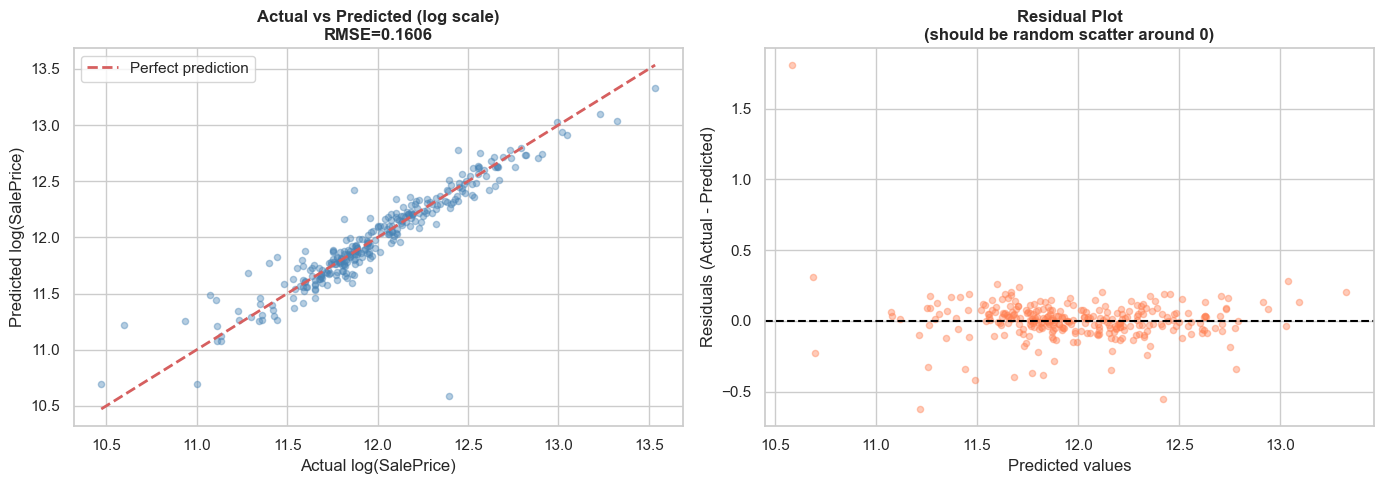

Reading the residual plot:
  Random scatter around 0 = good (linear model is appropriate)
  Pattern or curve = bad (non-linear relationship, linear model struggles)


In [52]:
# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log scale
axes[0].scatter(y_val, y_pred_val, alpha=0.4, s=20, color='steelblue')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()],
             'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual log(SalePrice)')
axes[0].set_ylabel('Predicted log(SalePrice)')
axes[0].set_title(f'Actual vs Predicted (log scale)\nRMSE={rmse:.4f}', fontweight='bold')
axes[0].legend()

# Residuals plot
residuals = y_val - y_pred_val
axes[1].scatter(y_pred_val, residuals, alpha=0.4, s=20, color='coral')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted values')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Plot\n(should be random scatter around 0)', fontweight='bold')

plt.tight_layout()
plt.show()

print("Reading the residual plot:")
print("  Random scatter around 0 = good (linear model is appropriate)")
print("  Pattern or curve = bad (non-linear relationship, linear model struggles)")

In [53]:
# Top coefficients — what does the model say matters most?
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("Top 15 most influential features (by coefficient magnitude):")
print()
print(f"{'Feature':<35} {'Coefficient':>12}  Interpretation")
print("-" * 75)

for _, row in coef_df.head(15).iterrows():
    direction = "increases" if row['coefficient'] > 0 else "decreases"
    print(f"{row['feature']:<35} {row['coefficient']:>12.4f}  {direction} price")

Top 15 most influential features (by coefficient magnitude):

Feature                              Coefficient  Interpretation
---------------------------------------------------------------------------
HasPool                                  -3.4138  decreases price
RoofMatl_WdShngl                          2.6803  increases price
RoofMatl_WdShake                          2.5262  increases price
RoofMatl_CompShg                          2.5108  increases price
RoofMatl_Roll                             2.4867  increases price
RoofMatl_Tar&Grv                          2.3931  increases price
RoofMatl_Metal                            2.3831  increases price
Condition2_PosN                          -0.8734  decreases price
BsmtFullBath                              0.8595  increases price
FullBath                                  0.8453  increases price
BsmtHalfBath                              0.6164  increases price
HasBasement                              -0.5304  decreases price
MSZon

## 8. The Problem with Plain Linear Regression on This Dataset

With 200+ features after encoding, Linear Regression overfits badly.
It tries to use every single feature, including noisy/irrelevant ones.

**Solution: Regularization**

- **Ridge (L2):** Shrinks all coefficients toward zero. Keeps all features but reduces their influence.
- **Lasso (L1):** Pushes some coefficients to exactly zero. Automatic feature selection.

Both add a penalty term to the loss:
```
Ridge: minimize MSE + alpha * sum(w^2)
Lasso: minimize MSE + alpha * sum(|w|)
```
`alpha` controls how much penalty — higher alpha = more regularization = simpler model.


In [54]:
# Cross-validation setup — 5 fold, shuffled
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_rmse(model, X, y):
    scores = -cross_val_score(model, X, y, cv=kf,
                               scoring='neg_root_mean_squared_error')
    return scores

# Plain Linear Regression CV
lr_cv = cv_rmse(Pipeline([('scaler', RobustScaler()), ('model', LinearRegression())]),
                X_all, y)
print(f"Linear Regression CV RMSE: {lr_cv.mean():.5f} ± {lr_cv.std():.5f}")

Linear Regression CV RMSE: 0.35260 ± 0.41302


In [55]:
# Ridge — auto-find best alpha using RidgeCV
alphas = [0.001, 0.01, 0.1, 1, 5, 10, 50, 100, 200, 500, 1000]

ridge_cv_model = RidgeCV(alphas=alphas, cv=kf, scoring='neg_root_mean_squared_error')
ridge_cv_model.fit(scaler.fit_transform(X_all), y)
best_ridge_alpha = ridge_cv_model.alpha_
print(f"Ridge — Best alpha: {best_ridge_alpha}")

ridge = Pipeline([('scaler', RobustScaler()), ('model', Ridge(alpha=best_ridge_alpha))])
ridge_scores = cv_rmse(ridge, X_all, y)
print(f"Ridge CV RMSE: {ridge_scores.mean():.5f} ± {ridge_scores.std():.5f}")

Ridge — Best alpha: 5.0
Ridge CV RMSE: 0.13065 ± 0.02008


In [57]:
# Lasso — auto-find best alpha
lasso_cv_model = LassoCV(alphas=alphas, cv=kf, max_iter=10000)
lasso_cv_model.fit(scaler.fit_transform(X_all), y)
best_lasso_alpha = lasso_cv_model.alpha_
print(f"Lasso — Best alpha: {best_lasso_alpha}")

lasso = Pipeline([('scaler', RobustScaler()), ('model', Lasso(alpha=best_lasso_alpha, max_iter=10000))])
lasso_scores = cv_rmse(lasso, X_all, y)
print(f"Lasso CV RMSE: {lasso_scores.mean():.5f} ± {lasso_scores.std():.5f}")

# How many features did Lasso zero out?
lasso.fit(X_all, y)
lasso_coefs = lasso.named_steps['model'].coef_
zeroed = (lasso_coefs == 0).sum()
print(f"Lasso zeroed out {zeroed} / {len(lasso_coefs)} features — automatic feature selection!")

Lasso — Best alpha: 0.001
Lasso CV RMSE: 0.13209 ± 0.02094
Lasso zeroed out 156 / 219 features — automatic feature selection!


Model                             CV RMSE      Std  Verdict
-----------------------------------------------------------------
Linear Regression                 0.35260  0.41302
Ridge (alpha=5.0)                 0.13065  0.02008 ← BEST
Lasso (alpha=0.001)               0.13209  0.02094

Lower RMSE = better. Kaggle leaderboard also uses log RMSE.


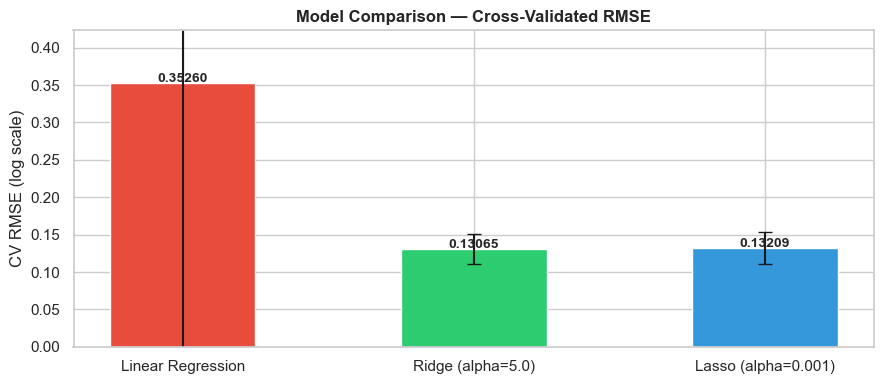

In [58]:
# Model comparison
models = {
    'Linear Regression': lr_cv,
    f'Ridge (alpha={best_ridge_alpha})': ridge_scores,
    f'Lasso (alpha={best_lasso_alpha})': lasso_scores,
}

print(f"{'Model':<30} {'CV RMSE':>10} {'Std':>8}  Verdict")
print("-" * 65)
best_rmse = min(s.mean() for s in models.values())
for name, scores in models.items():
    flag = " ← BEST" if abs(scores.mean() - best_rmse) < 0.0001 else ""
    print(f"{name:<30} {scores.mean():>10.5f} {scores.std():>8.5f}{flag}")

print()
print("Lower RMSE = better. Kaggle leaderboard also uses log RMSE.")

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
names = list(models.keys())
means = [s.mean() for s in models.values()]
stds  = [s.std()  for s in models.values()]
colors = ['#e74c3c' if m == max(means) else '#2ecc71' if m == min(means) else '#3498db'
          for m in means]
bars = ax.bar(names, means, yerr=stds, color=colors, capsize=5, edgecolor='white', width=0.5)
ax.set_ylabel('CV RMSE (log scale)')
ax.set_title('Model Comparison — Cross-Validated RMSE', fontweight='bold')
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{mean:.5f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, max(means) * 1.2)
plt.tight_layout()
plt.show()

Features kept by Lasso: 63 / 219



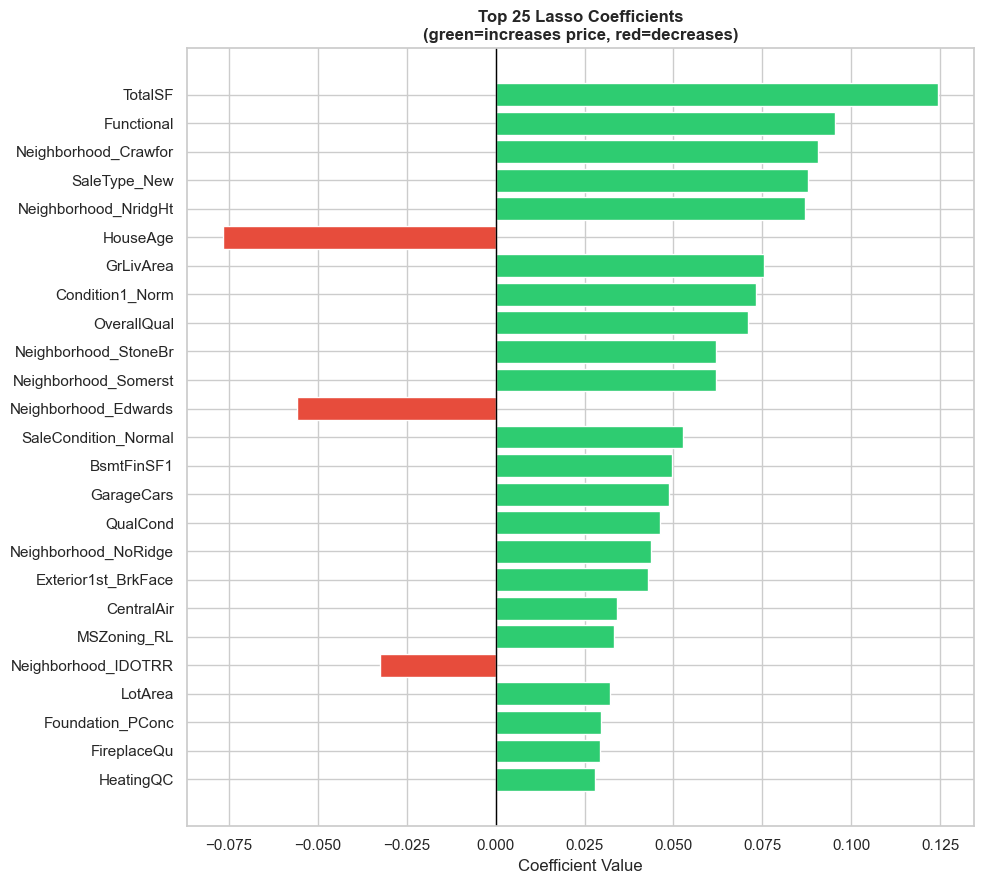

In [59]:
# Lasso feature importance — what survived?
lasso_feat_df = pd.DataFrame({
    'feature': X_all.columns,
    'coefficient': lasso_coefs
})
lasso_feat_df = lasso_feat_df[lasso_feat_df['coefficient'] != 0].sort_values(
    'coefficient', key=abs, ascending=False
)

print(f"Features kept by Lasso: {len(lasso_feat_df)} / {X_all.shape[1]}")
print()

fig, ax = plt.subplots(figsize=(10, 9))
top_lasso = lasso_feat_df.head(25)
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in top_lasso['coefficient']]
ax.barh(top_lasso['feature'], top_lasso['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Top 25 Lasso Coefficients\n(green=increases price, red=decreases)', fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Kaggle Submission

In [60]:
# Use the best model to predict on test set
best_model = ridge  # swap to lasso if lasso scored better above

best_model.fit(X_all, y)
test_preds_log = best_model.predict(X_test)

# Exponentiate back — we log-transformed the target, so reverse it
test_preds = np.expm1(test_preds_log)

print(f"Prediction stats:")
print(f"  Min:    ${test_preds.min():,.0f}")
print(f"  Max:    ${test_preds.max():,.0f}")
print(f"  Mean:   ${test_preds.mean():,.0f}")
print(f"  Median: ${np.median(test_preds):,.0f}")
print()
print("Sanity check — do these look like realistic house prices? ✓")

Prediction stats:
  Min:    $49,777
  Max:    $611,261
  Mean:   $177,725
  Median: $157,960

Sanity check — do these look like realistic house prices? ✓


In [61]:
SAMPLE_SUBMISSION_PATH = '../../Datasets/HousePrice/sample_submission.csv'

submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)
submission['SalePrice'] = test_preds

submission.to_csv('submission_linear.csv', index=False)
print("submission_linear.csv saved")
print()
print(submission.head(10))
print()
print("Next steps:")
print("  1. Upload submission_linear.csv to Kaggle")
print("  2. Note your public leaderboard score")
print("  3. Come back and compare when we do Random Forest (M4) and XGBoost (M8)")
print("     — you'll see exactly how much the model choice matters")

submission_linear.csv saved

     Id      SalePrice
0  1461  112381.485652
1  1462  155095.616113
2  1463  179529.181615
3  1464  196344.982431
4  1465  199866.083966
5  1466  167495.763505
6  1467  175271.287366
7  1468  160663.183323
8  1469  193892.928852
9  1470  120285.436239

Next steps:
  1. Upload submission_linear.csv to Kaggle
  2. Note your public leaderboard score
  3. Come back and compare when we do Random Forest (M4) and XGBoost (M8)
     — you'll see exactly how much the model choice matters


## What Linear Regression is Bad At — When NOT to Use It

| Situation | Problem | Use Instead |
|---|---|---|
| Non-linear relationships | LR draws straight lines only | Decision Tree, Random Forest |
| Many irrelevant features | Overfits without regularization | Lasso, Random Forest |
| Outliers in target | MSE punishes outliers heavily | Huber Regression, Tree models |
| Feature interactions | x1*x2 effects not captured | Polynomial features or Tree models |
| Classification | Wrong tool entirely | Logistic Regression |

**Where Linear Regression wins:**
- Highly interpretable — you can explain every prediction
- Fast — trains in milliseconds even on large datasets  
- Good baseline — if a fancier model doesn't beat it by much, stick with LR
- Extrapolates — can predict outside the training range (trees can't)

## ✅ Key Takeaways

- **Log-transform skewed targets** — essential for this dataset, reduces Kaggle RMSE significantly
- **Missing values here mean "None"** — domain knowledge changes your entire imputation strategy
- **Ordinal encoding > OHE for quality columns** — preserves the order (Ex > Gd > TA)
- **Ridge** — best when all features are potentially useful, shrinks noise
- **Lasso** — best for automatic feature selection, zeros out irrelevant features
- **Always use CV RMSE** not train RMSE — train RMSE will always look perfect with enough features
- **Coefficients tell a story** — OverallQual up by 1 point = +X% on price. Interpretability is Linear Regression's superpower.
